# Gemma session — carrier screening & scratch

Loads Gemma **once** into the kernel, then reuses it. Everything below calls
functions from `rk_scripts/screen_carriers.py` and `irc/`, so edits to those
files take effect without reloading the model (`%autoreload`).

Launch from the **repo root**:

```bash
uv run --group dev jupyter lab --no-browser --ip=0.0.0.0 --port=8888
```

Pick the model with `WB_MODE` (see `config.py`): `dev` = gemma-3-4b-it,
`prod` = gemma-3-27b-it. Set it *before* launching jupyter, or override
`MODEL_ID` in the load cell.

## 1. Setup

In [1]:
from irc import env  # MUST be the first import — loads .env/HF_HOME before hf reads it

%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

import pandas as pd
import torch
import matplotlib.pyplot as plt

from irc.paths import ARTIFACTS, REPO_ROOT

# rk_scripts/ and the repo root (for config.py) onto the path
for p in (REPO_ROOT, REPO_ROOT / "rk_scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import config
import screen_carriers as sc
from irc.model import ResidualCapture, chat_ids, get_decoder_layers, load_model, load_tokenizer
from irc.words_paper import CONCEPT_WORDS_PAPER, CONTROL_WORDS_PAPER, SENTENCES_PAPER

pd.set_option("display.width", 200, "display.max_colwidth", 80)
print(f"WB_MODE={config.MODE}  model={config.MODEL_ID}  layer={config.LAYER}")

WB_MODE=prod  model=google/gemma-3-27b-it  layer=40


## 2. Load Gemma (once)

Guarded so a stray re-run of this cell can't allocate a second copy of the
weights. To genuinely swap models, run the *unload* cell at the bottom first.

In [2]:
MODEL_ID = config.MODEL_ID   # or hard-code e.g. "google/gemma-3-27b-it"

if "model" not in globals():
    t0 = time.time()
    tokenizer = load_tokenizer(MODEL_ID)
    model = load_model(MODEL_ID)
    LAYERS = sc.all_layers(model)
    _cfg = getattr(model.config, "text_config", model.config)  # 27b is a multimodal ckpt
    print(f"loaded {MODEL_ID} in {time.time() - t0:.0f}s — "
          f"{len(LAYERS)} layers, d_model={_cfg.hidden_size}")
else:
    print(f"already loaded: {MODEL_ID} ({len(LAYERS)} layers) — skipping")

MID = LAYERS[len(LAYERS) // 2]   # default screening layer
MID

config.json:   0%|          | 0.00/972 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

loaded google/gemma-3-27b-it in 520s — 62 layers, d_model=5376


31

In [3]:
print(model.device, len(LAYERS), MODEL_ID)

cuda:0 62 google/gemma-3-27b-it


In [4]:
print(config.LAYER)


40


## 3. Embed the concept pool

Two encodings of the same 50 `CONCEPT_WORDS_PAPER`, both captured at **every**
layer in one pass — so the screening layer stays a slicing decision made later,
not a commitment made here.

- **`E_concept_wt`** (the default) — the word placed in each of the four
  `WORD_TEMPLATES_V1` and pooled over *only its own token positions*, averaged
  across templates. This is how `irc/concept_vectors.py` builds concept vectors:
  CLAUDE.md records it was adopted because the paper's last-prompt-token method
  failed sanity checks on Gemma. Caveat — `word_token_activations` wraps the text
  in Gemma's **chat template**, while carriers are embedded as bare text, so the
  two pools differ in framing as well as pooling.
- **`E_concept_bare`** — the lowercased word alone. Cheap (50 short forward
  passes against 200) but context-free, so at a mid-to-late layer its residual is
  shaped about as much by "what token comes next" as by the concept itself.

What *not* to do: mean-pool a whole template sentence (`"I've been thinking about
{word}."`). All 50 concepts would then share most of their tokens and collapse
toward a single direction, flattening the cosine range you're trying to read.

Which encoding to screen with is an empirical question, not a matter of taste —
set `E_concept`, then let the known-pairs diagnostic in §5 arbitrate at your
chosen layer.

In [5]:
CONCEPTS = list(CONCEPT_WORDS_PAPER)

from irc.concept_vectors import word_token_activations
from irc.words import WORD_TEMPLATES_V1

def concept_word_tokens(concepts, layers):
    """Concept embeddings the way irc/ builds concept vectors: the word placed in
    each of WORD_TEMPLATES_V1, pooled over ONLY the word's own token positions,
    averaged across templates."""
    out = []
    for i, w in enumerate(concepts):
        out.append(torch.stack([
            word_token_activations(model, tokenizer, t, w.lower(), layers)
            for t in WORD_TEMPLATES_V1
        ]).mean(0))
        if (i + 1) % 10 == 0 or i + 1 == len(concepts):
            print(f"  [word_tokens] {i + 1}/{len(concepts)}")
    return torch.stack(out)

t0 = time.time()
E_concept_wt   = concept_word_tokens(CONCEPTS, LAYERS)                            # in-context
E_concept_bare = sc.embed_concepts(model, tokenizer, LAYERS, "{word}", CONCEPTS)  # cheap baseline
print(f"word_tokens {tuple(E_concept_wt.shape)} | bare {tuple(E_concept_bare.shape)} "
      f"in {time.time() - t0:.0f}s")

E_concept = E_concept_wt   # what cells 4+ use; set to E_concept_bare to compare

  [word_tokens] 10/50
  [word_tokens] 20/50
  [word_tokens] 30/50
  [word_tokens] 40/50
  [word_tokens] 50/50
  [embed] concepts 25/50
  [embed] concepts 50/50
word_tokens (50, 62, 5376) | bare (50, 62, 5376) in 70s


## 4. Embed the candidate carriers and build the screen

In [6]:
carriers = sc.load_carriers()                       # the paper's 50
# carriers = sc.load_carriers(Path("my_candidates.txt"))          # + your own
# carriers = sc.load_carriers(Path("mine.txt"), include_paper=False)  # yours only

t0 = time.time()
E_carrier = sc.embed_all(model, tokenizer, carriers, LAYERS, "carriers")
print(f"{tuple(E_carrier.shape)} in {time.time() - t0:.0f}s")

long_df, summary = sc.build_tables(carriers, CONCEPTS, LAYERS, E_carrier, E_concept)
print(f"long_df {len(long_df):,} rows | summary {len(summary):,} rows")

  [embed] carriers 25/50
  [embed] carriers 50/50
(50, 62, 5376) in 333s
long_df 310,000 rows | summary 6,200 rows


In [7]:
sc.print_screen(summary, MID, n=15)


worst 15 carriers (L31, centered, highest max cosine first):

  +0.808  z= 1.24  Fragrant lilacs bloomed along the garden fence.
           -> Xylophones +0.808, Contraptions +0.784, Silver +0.781
  +0.793  z= 1.33  The museum exhibit featured ancient Egyptian artifacts.
           -> Poetry +0.793, Memories +0.789, Trees +0.786
  +0.749  z= 1.34  The coffee shop was bustling with morning customers.
           -> Memories +0.749, Phones +0.738, Poetry +0.729
  +0.730  z= 1.22  Children built sandcastles at the water's edge.
           -> Contraptions +0.730, Xylophones +0.723, Caverns +0.720
  +0.700  z= 1.50  The old photograph brought back forgotten memories.
           -> Memories +0.700, Poetry +0.609, Sadness +0.605
  +0.665  z= 1.28  He sketched the landscape with charcoal pencils.
           -> Xylophones +0.665, Silver +0.654, Dirigibles +0.648
  +0.630  z= 1.35  The movie theater was packed for the premiere.
           -> Memories +0.630, Phones +0.620, Poetry +0.616
  +0.629

In [ ]:
# The same as a dataframe, worst first. Threshold on z_max (how far the nearest
# concept stands out from THIS carrier's own distribution) rather than max_cos.
sc.screen_view(summary, MID, by="z_max").head(20)

## 5. Sanity-check the layer choice

The paper's list contains carriers that are obviously about a concept word.
A layer worth screening at should rank those pairs near the top. If none of the
layers does, the bare-word concept encoding is the thing to change (try
`CONCEPT_TEMPLATE`), not the layer.

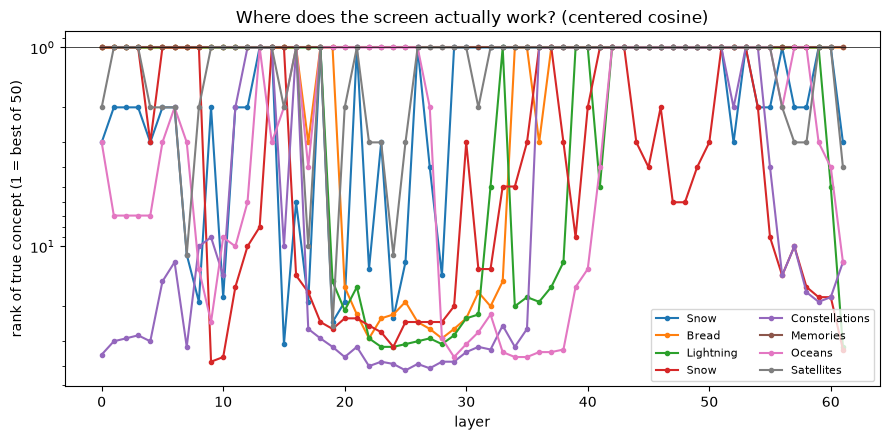

layer
51    1.000
53    1.000
43    1.000
42    1.000
46    1.125
14    1.250
54    1.250
50    1.250
44    1.250
49    1.375


In [8]:
KNOWN = [
    ("Snowflakes drifted lazily from the gray sky.", "Snow"),
    ("Fresh bread was baking in the oven.", "Bread"),
    ("Lightning flashed across the night sky.", "Lightning"),
    ("Mountains loomed in the distance, covered with snow.", "Snow"),
    ("Stars twinkled brightly in the clear night sky.", "Constellations"),
    ("The old photograph brought back forgotten memories.", "Memories"),
    ("Waves crashed against the rocky shoreline.", "Oceans"),
    ("The telescope revealed stunning details of Saturn's rings.", "Satellites"),
]

cen = long_df[long_df.variant == "centered"]
cen = cen.assign(rank=cen.groupby(["carrier_idx", "layer"]).cos.rank(ascending=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
for carrier, concept in KNOWN:
    r = cen[(cen.carrier == carrier) & (cen.concept == concept)].sort_values("layer")
    if len(r):
        ax.plot(r.layer, r["rank"], marker=".", label=f"{concept}")
ax.set_yscale("log"); ax.invert_yaxis()
ax.set_xlabel("layer"); ax.set_ylabel(f"rank of true concept (1 = best of {len(CONCEPTS)})")
ax.set_title("Where does the screen actually work? (centered cosine)")
ax.axhline(1, color="k", lw=0.5); ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

# Best layer = lowest mean rank on the known-contaminated pairs
pairs = pd.DataFrame(KNOWN, columns=["carrier", "concept"])
best = (cen.merge(pairs, on=["carrier", "concept"])
           .groupby("layer")["rank"].mean().sort_values())
print(best.head(10).to_string())

In [9]:
  best_all = cen.merge(pairs, on=["carrier", "concept"]).groupby("layer")["rank"].mean()
  print(f"layer 40: mean rank {best_all.loc[40]:.3f}  "
        f"(position {list(best_all.sort_values().index).index(40) + 1} of {len(best_all)})")

  # split the diagnostic: does the concept's surface form appear in the carrier?
  m = cen.merge(pairs, on=["carrier", "concept"])
  m["lexical"] = [c.lower() in s.lower() for s, c in zip(m.carrier, m.concept)]
  split = m.groupby(["lexical", "layer"])["rank"].mean().unstack(0)
  split.columns = ["semantic (n=3)", "lexical (n=5)"]
  print(split.loc[[14, 31, 40, 42, 43, 46, 50, 51, 53]].round(2))


layer 40: mean rank 2.625  (position 18 of 62)
       semantic (n=3)  lexical (n=5)
layer                               
14               1.67            1.0
31              20.33           10.8
40               5.00            1.2
42               1.00            1.0
43               1.00            1.0
46               1.00            1.2
50               1.00            1.4
51               1.00            1.0
53               1.00            1.0


In [10]:
# Print the whole late range:

split_all = m.groupby(["lexical", "layer"])["rank"].mean().unstack(0)
split_all.columns = ["semantic (n=3)", "lexical (n=5)"]
print(split_all.loc[35:61].round(2).to_string())

#  Then set the band from where the semantic column is actually at ceiling, contiguously:

ceiling = split_all[split_all["semantic (n=3)"] <= 1.5].index
band = list(range(int(ceiling.min()), int(ceiling.max()) + 1))   # contiguous
print(band)


       semantic (n=3)  lexical (n=5)
layer                               
35              21.00            4.8
36              12.00            5.0
37              12.00            4.0
38              11.67            3.6
39               6.00            2.6
40               5.00            1.2
41               2.00            1.8
42               1.00            1.0
43               1.00            1.0
44               1.00            1.4
45               1.00            1.6
46               1.00            1.2
47               1.00            2.0
48               1.00            2.0
49               1.00            1.6
50               1.00            1.4
51               1.00            1.0
52               1.33            1.4
53               1.00            1.0
54               1.00            1.4
55               2.00            2.8
56               6.00            3.6
57               4.67            3.0
58               7.00            4.2
59               7.67            4.4
6

## 6. Score new candidate carriers (concepts stay cached)

In [ ]:
def score(texts, layer=None, top_n=3):
    """Screen ad-hoc sentences against the cached concept pool."""
    layer = MID if layer is None else layer
    texts = [texts] if isinstance(texts, str) else list(texts)
    E = sc.embed_all(model, tokenizer, texts, LAYERS, "new")
    _, s = sc.build_tables(texts, CONCEPTS, LAYERS, E, E_concept, top_n)
    return sc.screen_view(s, layer)

score([
    "The kettle whistled just as the phone rang.",
    "He folded the letter twice and slid it under the door.",
    "Snowflakes drifted lazily from the gray sky.",   # known-bad control
])

## 7. Save the datafiles

In [ ]:
# §3 builds two concept pools; record which one this table came from. Identity
# check, so it needs no re-run of §3 (which would re-embed all 250 passes).
CONCEPT_POOL = ("E_concept_wt" if E_concept is E_concept_wt else
                "E_concept_bare" if E_concept is E_concept_bare else "custom")

# Band and slice layer come from §5, not config.LAYER: layer 40 sits two layers
# below the plateau where the known-pairs diagnostic reaches ceiling.
SCREEN_BAND  = list(range(42, 55))
SCREEN_LAYER = SCREEN_BAND[0]

out = sc.save_outputs(
    ARTIFACTS / "carrier_screen" / config.MODE,
    carriers, CONCEPTS, LAYERS, E_carrier, E_concept, long_df, summary,
    screen_layer=SCREEN_LAYER,
    # persist the pool this table was NOT built from, so the encoding question
    # can be reopened later without the GPU.
    extra_tensors={"E_concept_wt": E_concept_wt, "E_concept_bare": E_concept_bare},
    meta_extra={
        "model_id": MODEL_ID, "wb_mode": config.MODE,
        "source": "gemma_session.ipynb",
        "concept_pool": CONCEPT_POOL,
        "screen_band": SCREEN_BAND,
        # save_outputs' built-in "encoding" says bare text for both pools, which
        # is wrong for word_tokens. meta_extra merges last, so this corrects it.
        "encoding": {
            "carrier": "bare text, mean resid_post over own tokens, BOS excluded",
            "concept": {
                "E_concept_wt": "chat template, pooled over the word's own token "
                                "positions, averaged over WORD_TEMPLATES_V1",
                "E_concept_bare": "bare lowercased word, mean over own tokens",
            }.get(CONCEPT_POOL, "custom"),
        },
    },
)


## 8. Scratch — other things with the loaded model

Helpers for poking at activations without reloading anything.

In [ ]:
@torch.no_grad()
def acts_for(text, layers=None, chat=True):
    """(layers dict of (seq, d_model), token strings) — BOS dropped."""
    layers = LAYERS if layers is None else layers
    if chat:
        ids = chat_ids(tokenizer, text, device=model.device)
    else:
        ids = tokenizer(text, return_tensors="pt")["input_ids"].to(model.device)
    with ResidualCapture(model, layers) as cap:
        model(ids)
    toks = tokenizer.convert_ids_to_tokens(ids[0].tolist())
    return {l: cap.acts[l][0, 1:] for l in layers}, toks[1:]


@torch.no_grad()
def generate(text, max_new_tokens=64):
    ids = chat_ids(tokenizer, text, device=model.device)
    out = model.generate(ids, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(out[0, ids.shape[1]:], skip_special_tokens=True)


print(generate("Say the sentence 'The old clock on the wall ticked loudly.' and nothing else."))

In [ ]:
# Free the weights (only needed to swap models in this kernel)
# import gc
# for name in ("model", "tokenizer", "LAYERS"):
#     globals().pop(name, None)
# gc.collect(); torch.cuda.empty_cache()